# 01 -- Signal processing fundamentals: from waveform to spectrogram (and beyond)

Every model in this project (except the raw waveform itself) sees a
**spectrogram**, not the audio. This notebook builds that intuition from
scratch: what a spectrogram actually is, why the parameters you choose
matter for underwater bioacoustic signals specifically, and how
passive-sonar practitioners adapt these choices (linear vs. mel frequency
axis, window length, etc.) for their signals rather than borrowing
speech-processing defaults blindly.

It then goes one step further than a plain spectrogram, into two classic
passive-sonar analysis techniques -- **DEMON** and **matched filtering**
-- applied to species that produce literal biosonar click trains
(sperm whales, dolphins).

In [1]:
import os
import subprocess
import sys
import importlib.util

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Mount Drive and locate the project. Upload src/, configs/,
    #    pyproject.toml, requirements.txt to this path in My Drive first --
    #    NOT the multi-GB Watkins/ or results/ folders, those are handled
    #    separately below.
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DRIVE_PATH = "/content/drive/MyDrive/ShipsEAR"  # <-- edit if you used a different path
    if not os.path.exists(f"{PROJECT_DRIVE_PATH}/src/watkins"):
        raise FileNotFoundError(
            f"Expected the project's src/ folder at {PROJECT_DRIVE_PATH}/src on Google Drive.\n"
            "Upload src/, configs/, pyproject.toml, and requirements.txt there "
            "(skip the multi-GB Watkins/ and results/ folders), or edit "
            "PROJECT_DRIVE_PATH above to match where you put them."
        )
    sys.path.insert(0, f"{PROJECT_DRIVE_PATH}/src")

    # 2. Install whatever Colab's base image doesn't already have. Deliberately
    #    does NOT touch torch/torchaudio/torchvision -- Colab's preinstalled
    #    versions are already matched to its GPU + CUDA build, and reinstalling
    #    this project's CPU-only wheels here would silently disable the GPU.
    needed = ["transformers", "timm", "soundfile", "datasets", "huggingface_hub", "pyarrow"]
    missing = [pkg for pkg in needed if importlib.util.find_spec(pkg) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

    # 3. Data goes on fast local/ephemeral disk (re-derivable from the public
    #    Hugging Face source, no reason to pay Drive's slow random-I/O tax on
    #    thousands of per-epoch file reads); results go on Drive so trained
    #    checkpoints/metrics survive a runtime disconnect.
    os.environ["WATKINS_DATA_ROOT"] = "/content/watkins_data"
    os.environ["WATKINS_RESULTS_ROOT"] = f"{PROJECT_DRIVE_PATH}/results"

    from watkins.data import DATA_ROOT
    if not (DATA_ROOT / "manifest.csv").exists():
        print("Materializing the Watkins dataset locally -- one-time per Colab runtime, ~10-15 min...")
        subprocess.run([sys.executable, "-m", "watkins.prepare_data"], check=True)
else:
    sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import soundfile as sf

from watkins.data import load_manifest, CLASS_INFO, CLASS_IDS
from watkins.features import LogMelSpectrogram, lofar_gram, demon_spectrum, matched_filter, matched_filter_bank


## 1. The waveform

A handful of species, chosen to span the acoustic diversity in this
dataset: a tonal baleen-whale moan (humpback), a loud, common odontocete
(killer whale), a classic echolocation-click user (sperm whale), and a
pinniped (walrus, which produces knocks/clicks of its own). Even a 3-4
second clip is tens of thousands of samples -- far too many to reason
about individually, which is exactly why we need a time-frequency
representation.

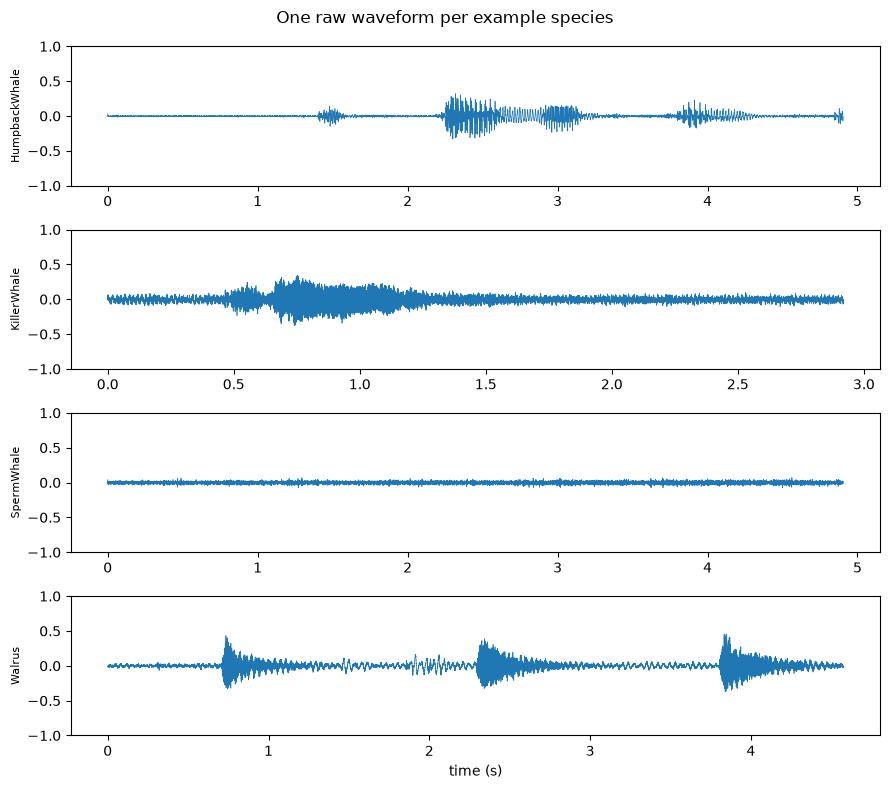

In [2]:
manifest = load_manifest()
by_class = {c: [clip for clip in manifest if clip.label == c] for c in CLASS_IDS}

EXAMPLE_SPECIES = [12, 22, 51, 21]  # HumpbackWhale, KillerWhale, SpermWhale, Walrus

fig, axes = plt.subplots(len(EXAMPLE_SPECIES), 1, figsize=(9, 8), sharex=False)
for ax, cid in zip(axes, EXAMPLE_SPECIES):
    clip = by_class[cid][0]
    y, sr = sf.read(clip.path)
    t = np.arange(len(y)) / sr
    ax.plot(t, y, linewidth=0.5)
    ax.set_ylabel(CLASS_INFO[cid]["display_name"], fontsize=8)
    ax.set_ylim(-1, 1)
axes[-1].set_xlabel("time (s)")
fig.suptitle("One raw waveform per example species")
plt.tight_layout()
plt.show()


## 2. STFT -> spectrogram: the core transform

A spectrogram slides a short analysis window across the waveform,
computes a Fourier transform inside each window (the Short-Time Fourier
Transform, STFT), and stacks the resulting frequency-magnitude vectors
side by side. Two parameters control everything:

- **window/FFT length** (`n_fft`): longer windows -> finer *frequency*
  resolution, coarser *time* resolution (a tonal's frequency becomes more
  precise, but you blur over fast transients).
- **hop length**: how far the window slides between frames. Smaller hop
  -> more overlap -> smoother spectrogram, more compute.

This is a real trade-off, not a knob to max out: a baleen whale's sustained
tonal moan benefits from frequency resolution, but an echolocation click
train is broadband and time-localized -- exactly the opposite need.
`LogMelSpectrogram` in `watkins/features.py` defaults to a 25ms window /
10ms hop (speech defaults) -- let's see whether that's actually a good
choice for a tonal call.

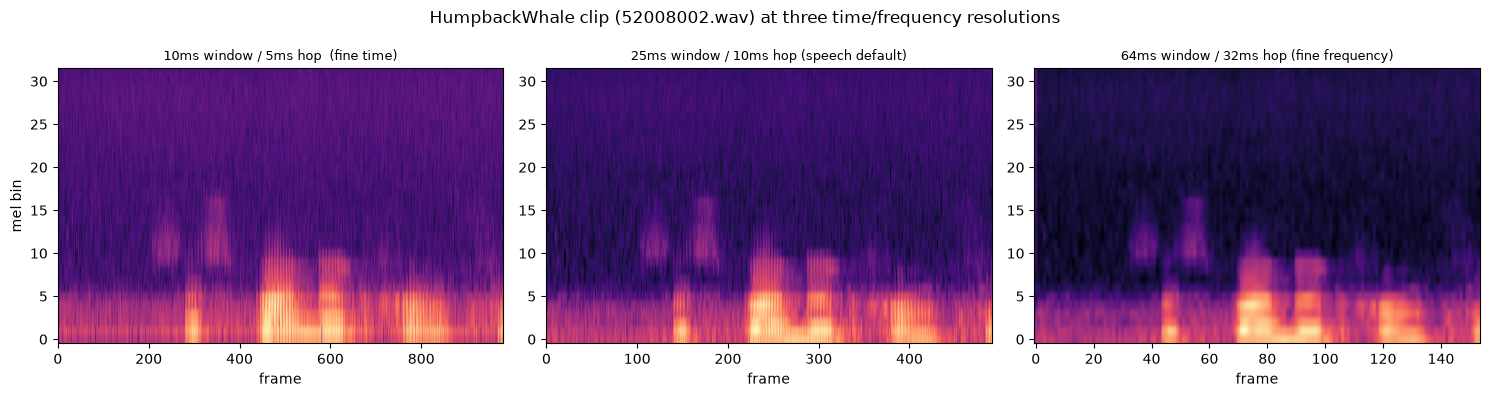

In [3]:
clip = by_class[12][0]  # HumpbackWhale -- sustained tonal moan
y, sr = sf.read(clip.path)
wav = torch.from_numpy(y.astype(np.float32)).unsqueeze(0)

configs = [
    ("10ms window / 5ms hop  (fine time)",   160, 80),
    ("25ms window / 10ms hop (speech default)", 400, 160),
    ("64ms window / 32ms hop (fine frequency)", 1024, 512),
]

fig, axes = plt.subplots(1, len(configs), figsize=(15, 4))
for ax, (title, n_fft, hop) in zip(axes, configs):
    feat = LogMelSpectrogram(n_fft=n_fft, hop_length=hop, n_mels=32, per_instance_normalize=False)
    spec = feat(wav).squeeze(0).numpy()
    ax.imshow(spec, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("frame")
ax0 = axes[0]; ax0.set_ylabel("mel bin")
fig.suptitle(f"HumpbackWhale clip ({clip.path.name}) at three time/frequency resolutions")
plt.tight_layout()
plt.show()


## 3. Mel scale vs. linear frequency: why passive sonar often prefers linear

The mel scale compresses frequency the way human hearing does -- lots of
resolution at low frequencies, very little at high ones. That's a
reasonable prior for speech. For a tonal call it's a more debatable
choice: harmonic components of a moan or whistle sit at fixed physical
frequencies, and mel warping smears them differently depending on where
they land, whereas a **LOFARgram** (LOw Frequency Analysis and
Recording) keeps a **linear** frequency axis specifically so a tonal
stays at a consistent row/position across recordings and is easy to
track by eye or algorithm.

Compare the two directly on the same clip:

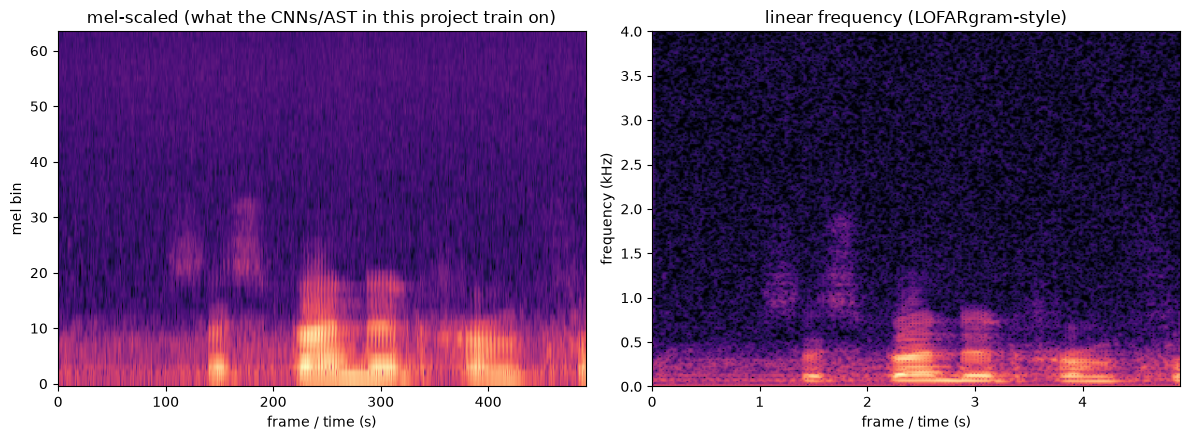

In [4]:
mel_feat = LogMelSpectrogram(n_mels=64, per_instance_normalize=False)
mel_spec = mel_feat(wav).squeeze(0).numpy()
lofar = lofar_gram(wav, n_fft=1024, hop_length=256).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(mel_spec, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("mel-scaled (what the CNNs/AST in this project train on)")
axes[0].set_ylabel("mel bin")
im = axes[1].imshow(lofar, aspect="auto", origin="lower", cmap="magma",
                     extent=[0, len(y) / sr, 0, sr / 2 / 1000])
axes[1].set_title("linear frequency (LOFARgram-style)")
axes[1].set_ylabel("frequency (kHz)")
axes[1].set_ylim(0, 4)  # most humpback call energy is below ~4kHz -- zoom in
for ax in axes:
    ax.set_xlabel("frame / time (s)")
plt.tight_layout()
plt.show()


Look for near-horizontal bright stripes in the linear-frequency plot --
those are tonal harmonics of the call's fundamental frequency, the same
way a musical note has overtones. This is the classic starting point for
classical (pre-deep-learning) passive-sonar target classification:
extract tonal frequencies and track them, rather than feed a whole image
to a classifier. Deep models trained on the mel spectrogram *can* still
pick up on this structure -- one open question for you to explore in
notebook 05's error analysis is whether misclassifications correlate
with clips where tonal harmonics are weak or absent.

## 4. Per-instance normalization

`LogMelSpectrogram` z-score normalizes each spectrogram independently by
default (subtract its own mean, divide by its own std). This dataset's
clips vary enormously in loudness (close vs. distant recordings, loud vs.
quiet species) -- without normalization, that loudness difference alone
would let a lazy model "solve" much of the task by intensity, rather than
by shape. Find the loudest and quietest clip in a small sample and
compare:

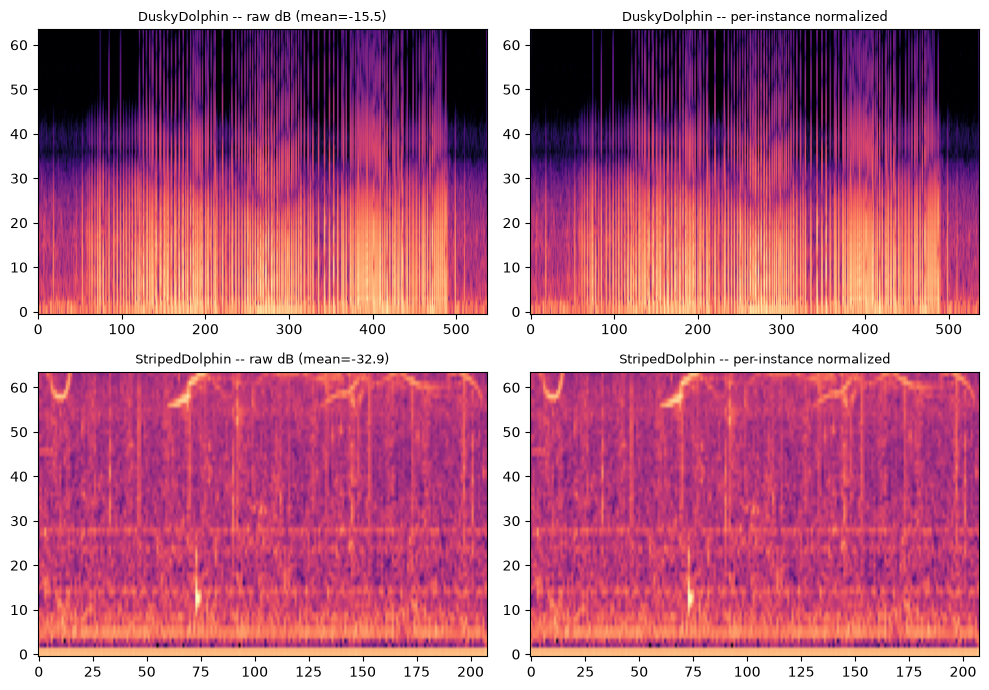

In [5]:
rng = np.random.default_rng(0)
sample = rng.choice(manifest, size=200, replace=False)
rms_vals = []
for clip in sample:
    y_s, sr_s = sf.read(clip.path)
    rms_vals.append(np.sqrt(np.mean(y_s.astype(np.float64) ** 2)))
rms_vals = np.array(rms_vals)
loud_clip, quiet_clip = sample[rms_vals.argmax()], sample[rms_vals.argmin()]

feat_norm = LogMelSpectrogram(per_instance_normalize=True)
feat_raw = LogMelSpectrogram(per_instance_normalize=False)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, clip in enumerate([loud_clip, quiet_clip]):
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    raw = feat_raw(w).squeeze(0).numpy()
    norm = feat_norm(w).squeeze(0).numpy()
    label = CLASS_INFO[clip.label]["display_name"]
    axes[row, 0].imshow(raw, aspect="auto", origin="lower", cmap="magma")
    axes[row, 0].set_title(f"{label} -- raw dB (mean={raw.mean():.1f})", fontsize=9)
    axes[row, 1].imshow(norm, aspect="auto", origin="lower", cmap="magma")
    axes[row, 1].set_title(f"{label} -- per-instance normalized", fontsize=9)
plt.tight_layout()
plt.show()


## 5. Beyond the spectrogram: DEMON analysis

A spectrogram of a click train (dolphin echolocation, sperm whale codas)
shows a smear of broadband energy at every click -- it doesn't directly
tell you *how often* the clicks repeat, which is often the most
diagnostic single number for that kind of call. **DEMON** (DEModulation
Of Envelope on Noise) is the classic passive-sonar technique for exactly
this: high-pass the signal, rectify it into an envelope, low-pass that
envelope, then take the FFT of *the envelope itself*. A periodic pulse
train produces a sharp peak in this "spectrum of the envelope" at its
repetition rate -- originally used to read a ship's propeller shaft/blade
rate off cavitation noise, and directly reusable here to read an
echolocating animal's click-repetition rate.

Compare a click-train species against a sustained tonal call, which has
no such periodicity to find:

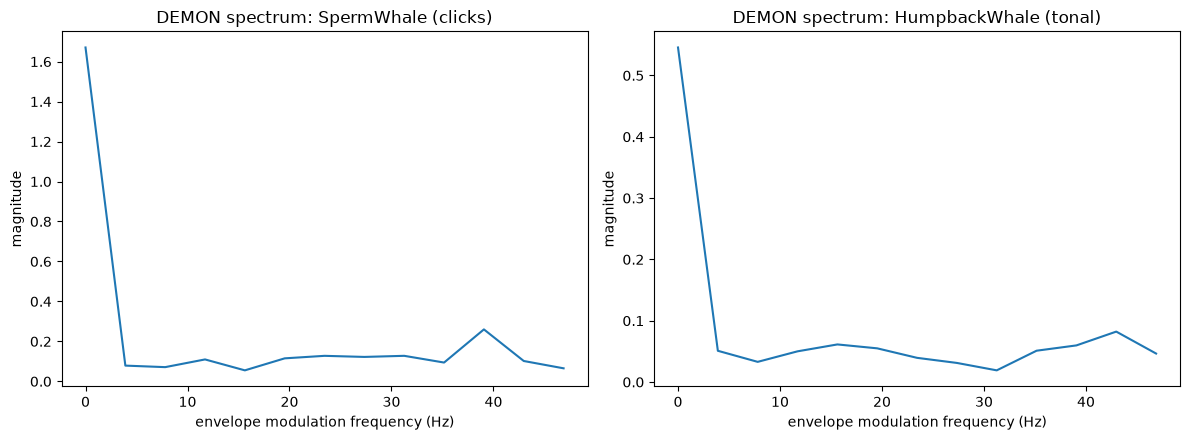

In [6]:
click_clip = by_class[51][0]   # SpermWhale -- echolocation clicks / codas
tonal_clip = by_class[12][0]   # HumpbackWhale -- sustained tonal moan

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, clip, title in zip(axes, [click_clip, tonal_clip], ["SpermWhale (clicks)", "HumpbackWhale (tonal)"]):
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    freqs, mag = demon_spectrum(w, sample_rate=sr_c)
    keep = freqs <= 50  # click-repetition rates of interest are typically single/low double digits Hz
    ax.plot(freqs[keep].numpy(), mag[keep].numpy())
    ax.set_title(f"DEMON spectrum: {title}")
    ax.set_xlabel("envelope modulation frequency (Hz)")
    ax.set_ylabel("magnitude")
plt.tight_layout()
plt.show()


Look for a sharp, isolated peak in the click-train species' DEMON
spectrum away from 0Hz -- that peak's frequency is (approximately) the
click-repetition rate, a number you could not read directly off a
spectrogram. The tonal call should look comparatively flat/unstructured,
since a sustained moan has no comparable pulse-train periodicity for
DEMON to expose.

## 6. Matched filtering: detecting a known target shape

The other classic sonar-analysis primitive is the **matched filter**:
slide a known reference template (a single averaged click or call shape)
across a signal and measure the correlation at every position. A peak
close to 1.0 marks where the template's shape appears in the signal --
this is how you'd *detect and time-align* a specific call type, as
opposed to classifying an already-isolated clip.

Build a short template from one clip and test it against another clip
from the same species vs. a different species:

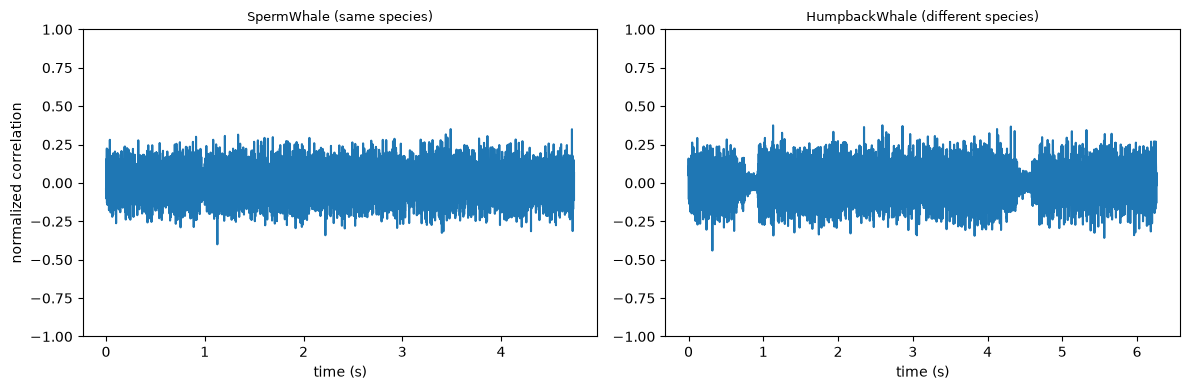

In [7]:
species_a, species_b = 51, 12  # SpermWhale, HumpbackWhale
template_clip = by_class[species_a][1]
y_t, sr_t = sf.read(template_clip.path)
template = torch.from_numpy(y_t[: int(0.05 * sr_t)].astype(np.float32))  # first 50ms as the template

test_clips = {
    f"{CLASS_INFO[species_a]['display_name']} (same species)": by_class[species_a][2],
    f"{CLASS_INFO[species_b]['display_name']} (different species)": by_class[species_b][2],
}

fig, axes = plt.subplots(1, len(test_clips), figsize=(12, 4))
for ax, (label, clip) in zip(axes, test_clips.items()):
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    response = matched_filter(w, template)
    ax.plot(np.arange(len(response)) / sr_c, response.numpy())
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("time (s)")
    ax.set_ylim(-1, 1)
axes[0].set_ylabel("normalized correlation")
plt.tight_layout()
plt.show()


## 7. A small template bank, not just one template

A single 50ms snippet is a narrow, unrepresentative stand-in for a
species' natural call shape -- amplitude, exact duration, and fine
structure all vary clip to clip and tape to tape. `matched_filter_bank`
scores a signal against several templates at once and takes the best
match at each position, the standard way a real filter bank combines
multiple templates rather than betting everything on one example.

Build a bank from four *different* SpermWhale clips (none of them the
test clip used above), and compare the full bank against just its first
member alone -- an apples-to-apples test of what the other three add:

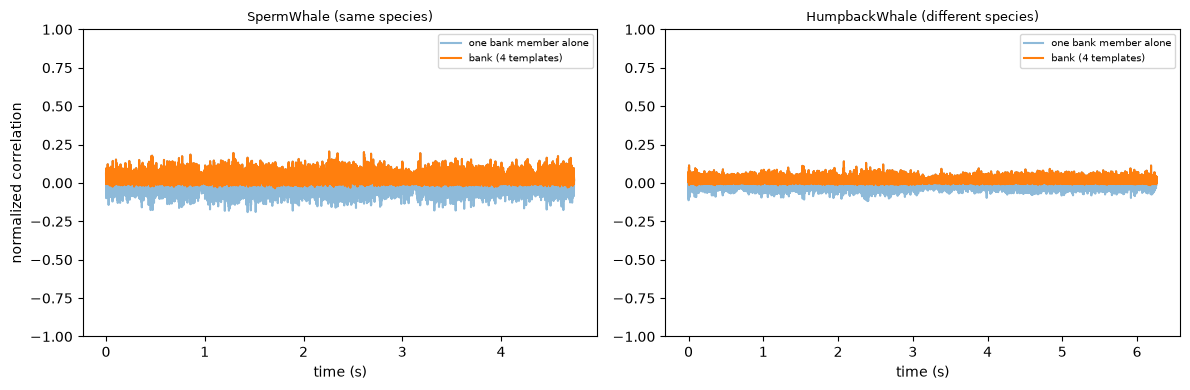

In [8]:
bank_clips = by_class[species_a][3:7]  # 4 different SpermWhale clips, distinct from the template/test clips above
template_bank = []
for c in bank_clips:
    y_b, sr_b = sf.read(c.path)
    template_bank.append(torch.from_numpy(y_b[: int(0.05 * sr_b)].astype(np.float32)))

fig, axes = plt.subplots(1, len(test_clips), figsize=(12, 4))
for ax, (label, clip) in zip(axes, test_clips.items()):
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    single_response = matched_filter(w, template_bank[0])  # one bank member alone, for a fair comparison
    bank_response = matched_filter_bank(w, template_bank)
    t_axis = np.arange(len(bank_response)) / sr_c
    ax.plot(t_axis, single_response.numpy(), alpha=0.5, label="one bank member alone")
    ax.plot(t_axis, bank_response.numpy(), label=f"bank ({len(template_bank)} templates)")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("time (s)")
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7)
axes[0].set_ylabel("normalized correlation")
plt.tight_layout()
plt.show()

The bank's response is never *below* the single template's -- it's an
elementwise max across templates, so it can only tie or beat it. The
real question is whether it raises the **same-species** peak more than
it raises the **different-species** one. If so, the bank genuinely
improved separability; if both rise together, the extra templates are
adding more chances to match by coincidence, not more discriminating
power. Note this is still far short of a deployment-grade detector --
see the next slide in `docs/theory-deck` for what real passive-sonar
systems add on top of this.

## Exercises

1. The default config uses 64 mel bins. Try 32 and 128 -- inspect the
   resulting spectrogram images. At what point does more resolution stop
   visibly helping for a 3-4 second clip like this?
2. Zoom the LOFARgram plot into 0-1kHz for the humpback clip. Can you
   count distinct harmonic lines? Roughly estimate their frequency
   spacing.
3. `f_max` in `LogMelSpectrogram` defaults to the Nyquist frequency
   (8kHz for 16kHz audio). Given that odontocete clicks/whistles often
   extend past that ceiling (see `features.py`'s module docstring), what
   is this pipeline definitely *not* able to see for those species?
4. Re-run the DEMON comparison on a couple more echolocating species
   (e.g. `BottlenoseDolphin`, id 14, or `KillerWhale`, id 22 -- orcas both
   echolocate and produce tonal calls). Do their click-repetition-rate
   peaks land at noticeably different frequencies from the sperm whale's?
   A real difference here would be a genuinely useful hand-engineered
   feature for a classifier.
5. Grow the template bank from 4 templates to 8-10 (more clips from
   `by_class[species_a]`). Does the same-species/different-species gap
   in section 7's plot widen, stay flat, or shrink? A shrinking gap means
   the extra templates are adding false-match opportunities faster than
   they're adding real discriminating power -- worth knowing before you
   assume "more templates is always better."
6. Try building a bank from a *different* species with more tapes
   available (see `docs/class_reference.md`) and cross-test it against
   several other species' clips, not just one. Does the bank's
   same-species advantage hold up, or was the sperm whale/humpback pair
   an easy case?